# Capstone Project: Initial Report and Exploratory Data Analysis

**Capstone question:** Do customers with similar revenue, tenure, and subscription plans receive different discounts?

## 1. Data loading

Load the dataset as a Data Frame and explore the first five rows.

In [121]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('../data/data.csv')
data.head()

,customer_key,mrr_net,mrr_list,discount_amount,discount_pct,current_depth_bucket,primary_plan_id,primary_plan_name,interval,interval_count,plan_count,first_active_date,tenure_days,acquisition_channel,was_active_90d_ago,depth_90d_ago,had_coupon_in_last_90d
0,customer_9eed025ecb18228e053359a5,12.50,12.50,0.00,0.0000,full_price,plan_053,Annual Plan,year,1,1,2019-12-15,2480,discount,True,0.0000,False
1,customer_ac7fb0a0b5080ef5c4106d24,9.99,9.99,0.00,0.0000,full_price,plan_009,Monthly Plan,month,1,1,2025-12-31,272,full_price,True,0.0000,False
2,customer_1f843cd596b6377f87d5278f,24.99,24.99,0.00,0.0000,full_price,plan_052,HiFi Monthly Plan,month,1,1,2026-09-06,23,full_price,False,NaN,False
3,customer_c5115fe9cba9c4d25fba1456,8.33,16.66,8.33,0.5001,deep,plan_035,Annual $99 Promotion,year,1,1,2025-12-03,300,discount,True,0.5001,True
4,customer_9dca67c627c6bd0824169a52,8.33,16.66,8.33,0.5001,deep,plan_065,All-Access Plan,year,1,1,2022-01-10,1723,full_price,True,0.5001,True


## 2. Data validation and cleaning

Inspect data types, missing values, duplicates, outliers, and inconsistent category labels.

In [122]:
print('Rows:', data.shape[0])
print('Columns:', data.shape[1])
data.info()

Rows: 114440
Columns: 17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114440 entries, 0 to 114439
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   customer_key            114440 non-null  object 
 1   mrr_net                 114440 non-null  float64
 2   mrr_list                114440 non-null  float64
 3   discount_amount         114440 non-null  float64
 4   discount_pct            114322 non-null  float64
 5   current_depth_bucket    114322 non-null  object 
 6   primary_plan_id         114440 non-null  object 
 7   primary_plan_name       114440 non-null  object 
 8   interval                114440 non-null  object 
 9   interval_count          114440 non-null  int64  
 10  plan_count              114440 non-null  int64  
 11  first_active_date       114440 non-null  object 
 12  tenure_days             114440 non-null  int64  
 13  acquisition_channel     114439 non-null  object 


Preview values described as object to understand what they hold

In [123]:
data.select_dtypes(include='object').head()

,customer_key,current_depth_bucket,primary_plan_id,primary_plan_name,interval,first_active_date,acquisition_channel
0,customer_9eed025ecb18228e053359a5,full_price,plan_053,Annual Plan,year,2019-12-15,discount
1,customer_ac7fb0a0b5080ef5c4106d24,full_price,plan_009,Monthly Plan,month,2025-12-31,full_price
2,customer_1f843cd596b6377f87d5278f,full_price,plan_052,HiFi Monthly Plan,month,2026-09-06,full_price
3,customer_c5115fe9cba9c4d25fba1456,deep,plan_035,Annual $99 Promotion,year,2025-12-03,discount
4,customer_9dca67c627c6bd0824169a52,deep,plan_065,All-Access Plan,year,2022-01-10,full_price


Here we can see that `customer_key` and `primary_plan_id` are identifiers, `current_depth_bucket`, `primary_plan_name`, `interval` and `acquisition_channel` are categorical, and `first_active_date` represents a date. We will keep them as objects for now.

Let's explore the distinct values in each categorical column:

In [124]:
categorical_columns = [
    'current_depth_bucket',
    'primary_plan_name',
    'interval',
    'acquisition_channel'
]

for column in categorical_columns:
    print(column)
    print(data[column].unique())
    print()

current_depth_bucket
['full_price' 'deep' 'light' 'heavy' nan]

primary_plan_name
['Annual Plan' 'Monthly Plan' 'HiFi Monthly Plan' 'Annual $99 Promotion'
 'All-Access Plan' 'Seasonal Promotion' 'HiFi Annual Plan'
 'All-Access Annual Plan' 'Two-Month Promotion' 'Welcome Offer - Monthly'
 'All-Access Monthly Plan' 'Welcome Offer - Annual' 'Monthly Trial Plan'
 'Four-Month $5 Promotion' 'Annual Trial Plan' 'Promotional Plan'
 'Streaming Annual Plan' 'Standard Plan' 'One-Month 50% Promotion'
 'Streaming Monthly Plan' 'Multi-Use Promotion']

interval
['year' 'month']

acquisition_channel
['discount' 'full_price' nan]



We can see that there are `nan` values on `current_depth_bucket` and `acquisition_channel`. Let's count them to understand how many they are:

In [125]:
missing_values = pd.DataFrame({
    'count': data.isna().sum(),
    'percentage': data.isna().mean() * 100
})

missing_values[missing_values['count'] > 0].sort_values(
    'count', ascending=False
).round(3)

,count,percentage
depth_90d_ago,25814,22.557
discount_pct,118,0.103
current_depth_bucket,118,0.103
acquisition_channel,1,0.001


Were customers with a missing historical discount active 90 days ago?

In [126]:
data.loc[
    data['depth_90d_ago'].isna(),
    'was_active_90d_ago'
].value_counts()

was_active_90d_ago
False    25805
True         9
Name: count, dtype: int64

Of the 25,814 missing historical discount percentages, 25,805 belong to customers who were not active 90 days earlier. Nine belong to customers who were active, but the historical percentage is also missing. We keep these values undefined.

What do the customers with a missing current discount percentage have in common?


In [127]:
data.loc[
    data['discount_pct'].isna(),
    ['mrr_list', 'mrr_net', 'discount_amount',
     'discount_pct', 'current_depth_bucket']
].describe()

,mrr_list,mrr_net,discount_amount,discount_pct
count,118.0,118.0,118.0,0.0
mean,0.0,0.0,0.0,NaN
std,0.0,0.0,0.0,NaN
min,0.0,0.0,0.0,NaN
25%,0.0,0.0,0.0,NaN
50%,0.0,0.0,0.0,NaN
75%,0.0,0.0,0.0,NaN
max,0.0,0.0,0.0,NaN


The 118 missing discount percentages correspond to customers with zero list price and zero net revenue. We exclude them from the discount analysis because their discount percentage cannot be calculated. This also removes the 118 missing discount buckets.

In [128]:
clean_data = data.dropna(subset=['discount_pct']).copy()

print('Rows removed:', data.shape[0] - clean_data.shape[0])
print('Rows remaining:', clean_data.shape[0])

Rows removed: 118
Rows remaining: 114322


Now let's review the row without `acquisition_channel`

In [129]:
clean_data.loc[clean_data['acquisition_channel'].isna()]

,customer_key,mrr_net,mrr_list,discount_amount,discount_pct,current_depth_bucket,primary_plan_id,primary_plan_name,interval,interval_count,plan_count,first_active_date,tenure_days,acquisition_channel,was_active_90d_ago,depth_90d_ago,had_coupon_in_last_90d
90351,customer_9ad74f143735a3e5ef928d0f,14.99,14.99,0.0,0.0,full_price,plan_012,Promotional Plan,month,1,1,2026-07-29,62,NaN,False,NaN,False


We exclude the customer with a missing acquisition channel because its acquisition category is unknown.

In [130]:
rows_before = clean_data.shape[0]

clean_data = clean_data.dropna(subset=['acquisition_channel']).copy()

print('Rows removed:', rows_before - clean_data.shape[0])
print('Rows remaining:', clean_data.shape[0])

Rows removed: 1
Rows remaining: 114321


Now, let's explore duplicates:

In [131]:
print('Duplicate rows:', clean_data.duplicated().sum())
print(
    'Duplicate customer keys:',
    clean_data['customer_key'].duplicated().sum()
)

Duplicate rows: 0
Duplicate customer keys: 0


No duplicate rows or customer identifiers were found, so no further records were removed.

Let's look for impossible ranges, unusual extremes or columns with no variations:

In [132]:
clean_data.describe().T

,count,mean,std,min,25%,50%,75%,max
mrr_net,114321.0,12.408770,5.106666,0.0,8.33,12.50,14.9900,49.9900
mrr_list,114321.0,15.319655,3.625799,2.0,12.50,14.99,16.6600,74.9500
discount_amount,114321.0,2.910885,4.064250,0.0,0.00,0.00,8.3300,50.0000
discount_pct,114321.0,0.183629,0.256651,0.0,0.00,0.00,0.5001,1.0000
interval_count,114321.0,1.000000,0.000000,1.0,1.00,1.00,1.0000,1.0000
plan_count,114321.0,1.031140,0.173949,1.0,1.00,1.00,1.0000,3.0000
tenure_days,114321.0,978.123468,892.968061,0.0,226.00,675.00,1606.0000,4344.0000
depth_90d_ago,88592.0,0.147911,0.221664,0.0,0.00,0.00,0.5001,0.5001


The numeric summary shows no obvious invalid ranges. Discount percentages range from 0 to 1 (0% to 100%), list revenue is positive, tenure is non-negative, and customers have between one and three plans. Zero net revenue can be valid when a customer receives a 100% discount.

In [133]:
clean_data.isna().sum()

customer_key                  0
mrr_net                       0
mrr_list                      0
discount_amount               0
discount_pct                  0
current_depth_bucket          0
primary_plan_id               0
primary_plan_name             0
interval                      0
interval_count                0
plan_count                    0
first_active_date             0
tenure_days                   0
acquisition_channel           0
was_active_90d_ago            0
depth_90d_ago             25729
had_coupon_in_last_90d        0
dtype: int64

After cleaning, 114,321 customers remain, with no duplicate rows or customer identifiers. Missing historical discount percentages are retained as undefined.

## 3. Exploratory data analysis

First, we examine how discount percentages are distributed across customers to identify common discount levels.

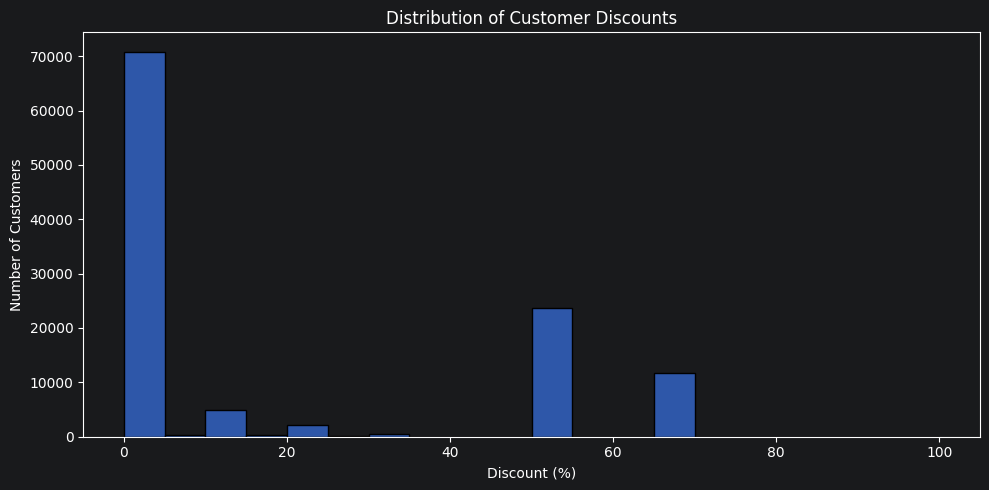

In [134]:
plt.figure(figsize=(10, 5))

sns.histplot(x=clean_data['discount_pct'] * 100, bins=20)

plt.title('Distribution of Customer Discounts')
plt.xlabel('Discount (%)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Most customers receive little or no discount. Other noticeable concentrations occur around 50% and 65–70%, suggesting common discount tiers. Discounts are therefore concentrated at a few levels rather than evenly distributed.

Next, we compare discounts for monthly and annual subscriptions.

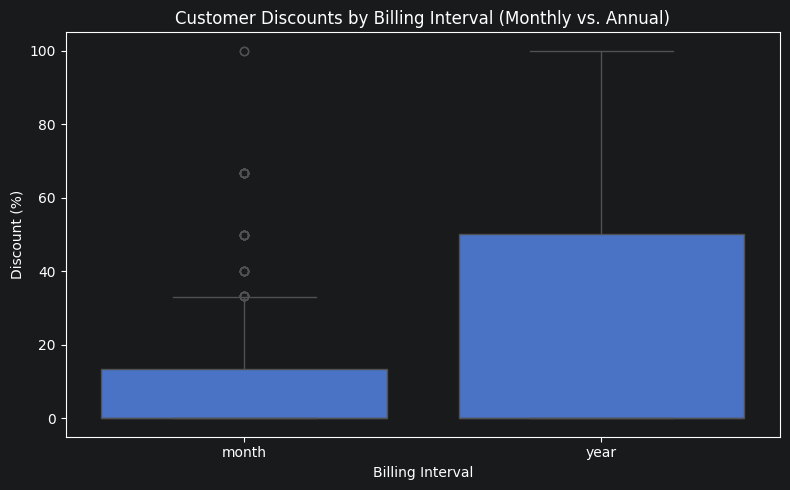

interval
month    0.0
year     0.0
Name: discount_pct, dtype: float64

In [135]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=clean_data['interval'],
    y=clean_data['discount_pct'] * 100,
    order=['month', 'year']
)

plt.title('Customer Discounts by Billing Interval (Monthly vs. Annual)')
plt.xlabel('Billing Interval')
plt.ylabel('Discount (%)')
plt.tight_layout()
plt.show()

clean_data.groupby('interval')['discount_pct'].median() * 100

Both monthly and annual subscribers have a median discount of 0%. Annual subscriptions show greater variation: the middle 50% of discounts extends from 0% to approximately 50%, compared with approximately 0–13% for monthly subscriptions.

Let's now examine the relationship between customer tenure and discount percentage, distinguishing monthly and annual subscriptions.

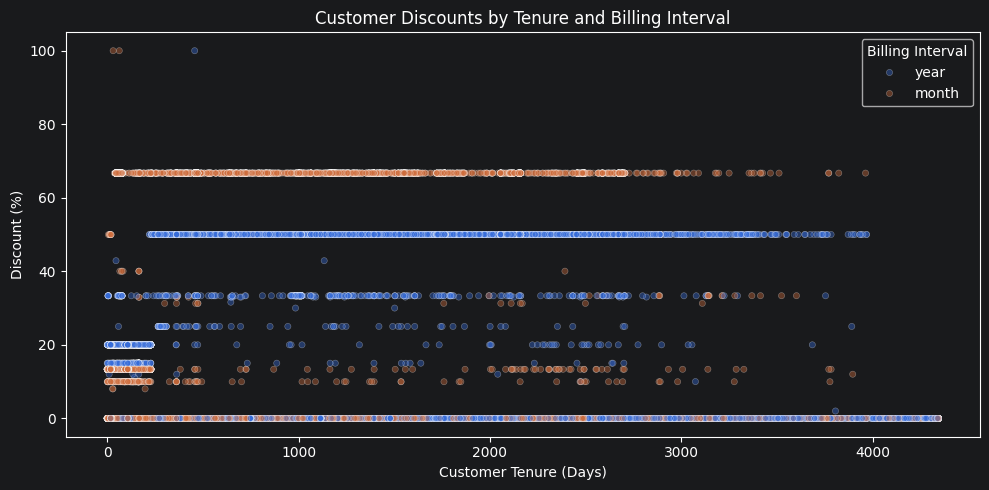

In [136]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=clean_data,
    x='tenure_days',
    y=clean_data['discount_pct'] * 100,
    hue='interval',
    alpha=0.4,
    s=20
)

plt.title('Customer Discounts by Tenure and Billing Interval')
plt.xlabel('Customer Tenure (Days)')
plt.ylabel('Discount (%)')
plt.legend(title='Billing Interval')
plt.tight_layout()
plt.show()

Discounts form horizontal bands at common levels, particularly around 0%, 50%, and 67%, across a wide range of customer tenures. There is no clear increase or decrease in discounts with tenure, suggesting that tenure alone may not explain the differences.

Plan names were generalized during anonymization, and multiple plan IDs can share the same label. The following chart provides an overview by label, but differences within a label do not necessarily represent differences within the same plan. We will use plan IDs for more precise customer comparisons.

In [137]:
plans_per_label = clean_data.groupby(
    'primary_plan_name'
)['primary_plan_id'].nunique()

plans_per_label[plans_per_label > 1].sort_values(ascending=False)

primary_plan_name
Promotional Plan           11
Monthly Trial Plan          7
All-Access Plan             6
Annual Plan                 5
HiFi Annual Plan            5
HiFi Monthly Plan           5
All-Access Annual Plan      4
All-Access Monthly Plan     4
Monthly Plan                4
Standard Plan               4
Annual Trial Plan           3
Seasonal Promotion          2
Streaming Annual Plan       2
Name: primary_plan_id, dtype: int64

Now we compare the percentage of customers in each discount bucket across plan labels.

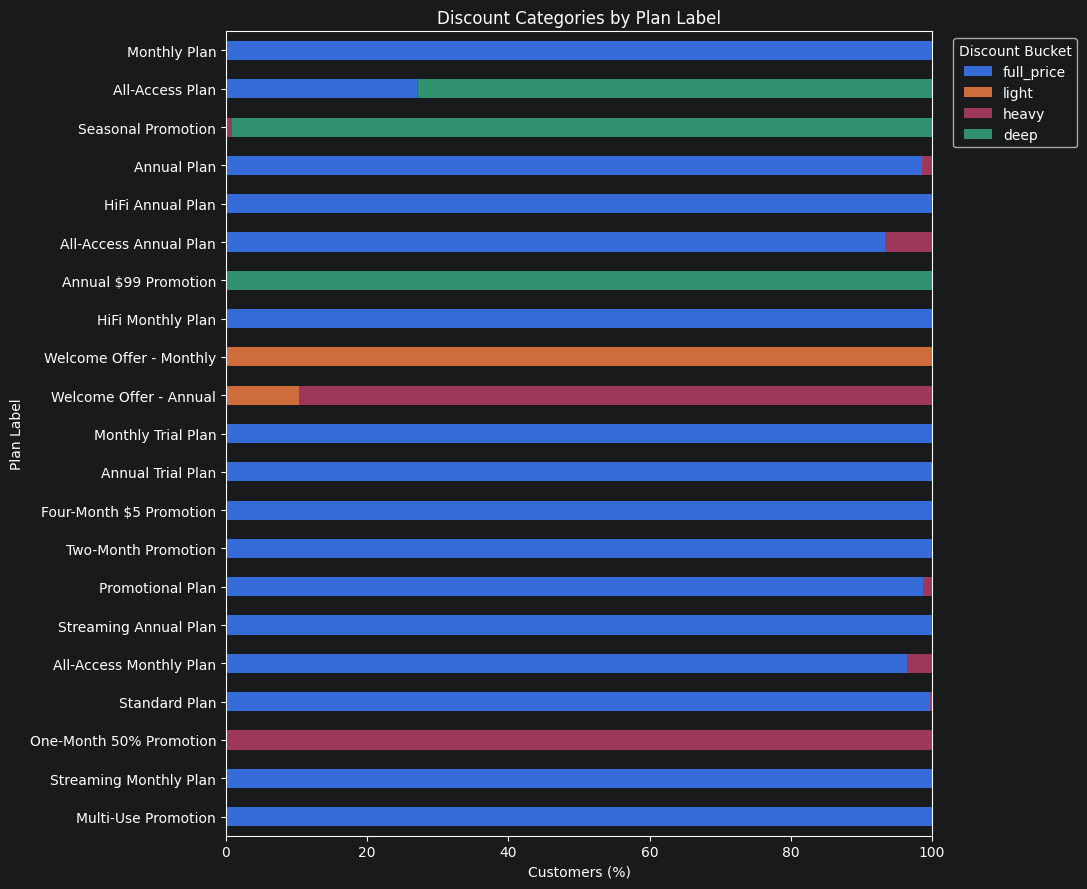

In [138]:
plan_order = clean_data['primary_plan_name'].value_counts().index

discount_mix = pd.crosstab(
    clean_data['primary_plan_name'],
    clean_data['current_depth_bucket'],
    normalize='index'
) * 100

discount_mix = discount_mix.reindex(
    index=plan_order,
    columns=['full_price', 'light', 'heavy', 'deep'],
    fill_value=0
)

ax = discount_mix.plot(
    kind='barh',
    stacked=True,
    figsize=(11, 9)
)

ax.invert_yaxis()
plt.title('Discount Categories by Plan Label')
plt.xlabel('Customers (%)')
plt.ylabel('Plan Label')
plt.xlim(0, 100)
plt.legend(title='Discount Bucket', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Most plan labels are dominated by customers paying full price. Seasonal Promotion and Annual $99 Promotion are mainly associated with deep discounts, while All-Access Plan contains a substantial mix of full-price and deeply discounted customers. These differences suggest that plan information matters when defining comparable customer groups.

Let's now explore how discount percentages vary with monthly list price:

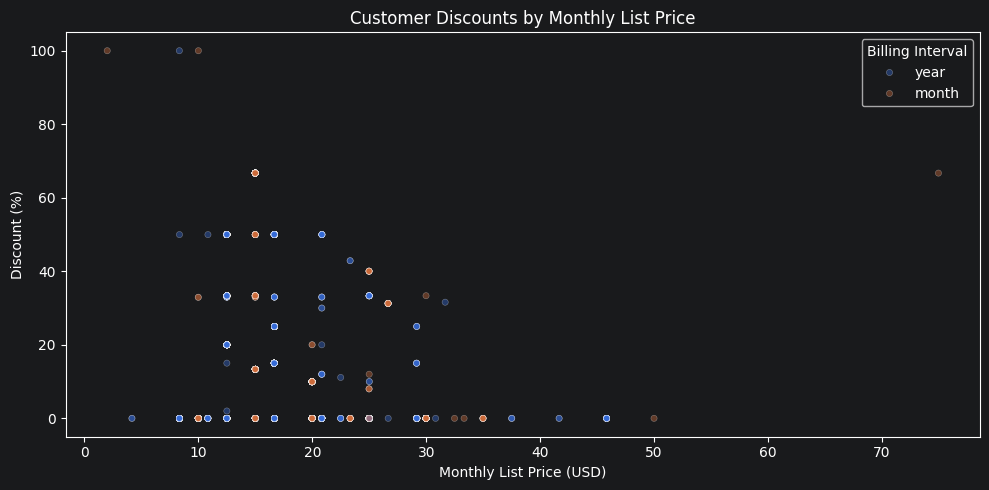

In [139]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=clean_data,
    x='mrr_list',
    y=clean_data['discount_pct'] * 100,
    hue='interval',
    alpha=0.4,
    s=20
)

plt.title('Customer Discounts by Monthly List Price')
plt.xlabel('Monthly List Price (USD)')
plt.ylabel('Discount (%)')
plt.legend(title='Billing Interval')
plt.tight_layout()
plt.show()

Customers with similar monthly list prices receive different discount percentages. List price alone therefore does not uniquely determine the discount.

We can use the interquartile range (IQR) to flag unusually low or high monthly list prices.


In [140]:
q1, q3 = clean_data['mrr_list'].quantile([0.25, 0.75])
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

price_outliers = clean_data[
    (clean_data['mrr_list'] < lower) |
    (clean_data['mrr_list'] > upper)
]

print('Lower bound:', round(lower, 2))
print('Upper bound:', round(upper, 2))
print('Potential outliers:', price_outliers.shape[0])

price_outliers.sort_values('mrr_list', ascending=False)[
    ['mrr_list', 'discount_pct', 'primary_plan_name', 'plan_count']
].head(10)

Lower bound: 6.26
Upper bound: 22.9
Potential outliers: 8139


,mrr_list,discount_pct,primary_plan_name,plan_count
112424,74.95,0.6671,Seasonal Promotion,1
102857,49.99,0.0000,HiFi Monthly Plan,3
56303,45.83,0.0000,HiFi Annual Plan,2
63575,45.83,0.0000,HiFi Annual Plan,2
49832,45.83,0.0000,HiFi Annual Plan,2
11167,45.83,0.0000,HiFi Annual Plan,2
100084,45.83,0.0000,HiFi Annual Plan,2
66194,45.83,0.0000,HiFi Annual Plan,2
29494,45.83,0.0000,HiFi Annual Plan,2
49087,45.83,0.0000,HiFi Annual Plan,2


The IQR rule flags 8,139 customers with unusually low or high monthly list prices. Several of the highest-price customers have multiple plans, which may explain their higher totals. The highest-price customer has only one plan and should be looked at more closely. We retain these observations for now because an unusual price alone does not establish a data error.

We inspect customers below the lower IQR bound to understand whether their prices may reflect valid low-cost subscriptions.

In [141]:
low_price_outliers = clean_data[
    clean_data['mrr_list'] < lower
]

print('Low-price outliers:', low_price_outliers.shape[0])

low_price_outliers.sort_values('mrr_list')[
    ['mrr_list', 'mrr_net', 'discount_amount',
     'discount_pct', 'primary_plan_name', 'plan_count']
].head(10)

Low-price outliers: 3


,mrr_list,mrr_net,discount_amount,discount_pct,primary_plan_name,plan_count
30790,2.00,0.00,2.0,1.0,Welcome Offer - Monthly,1
53664,4.17,4.17,0.0,0.0,Annual Plan,1
107830,4.17,4.17,0.0,0.0,Annual Plan,1


Three customers have monthly list prices below `$6.26`. One has a `$2` list price and a 100% discount, while the other two have `$4.17` list prices and pay in full.

We can now summarize high-price observations by plan ID to determine whether they are concentrated in particular subscription plans.

In [142]:
high_price_outliers = clean_data[
    clean_data['mrr_list'] > upper
]

high_price_outliers.groupby(
    ['primary_plan_id', 'primary_plan_name']
).agg(
    flagged_customers=('customer_key', 'count'),
    min_list_price=('mrr_list', 'min'),
    max_list_price=('mrr_list', 'max')
).sort_values('flagged_customers', ascending=False).head(10)

,,flagged_customers,min_list_price,max_list_price
primary_plan_id,primary_plan_name,,,
plan_052,HiFi Monthly Plan,3822,24.99,24.99
plan_067,HiFi Monthly Plan,1753,24.99,49.99
plan_058,HiFi Monthly Plan,829,24.99,24.99
plan_070,All-Access Plan,496,24.99,34.98
plan_056,HiFi Annual Plan,478,25.00,45.83
plan_049,Monthly Trial Plan,444,24.99,24.99
plan_042,Monthly Trial Plan,156,24.99,24.99
plan_053,Annual Plan,53,25.00,29.17
plan_011,Monthly Plan,32,23.32,32.48


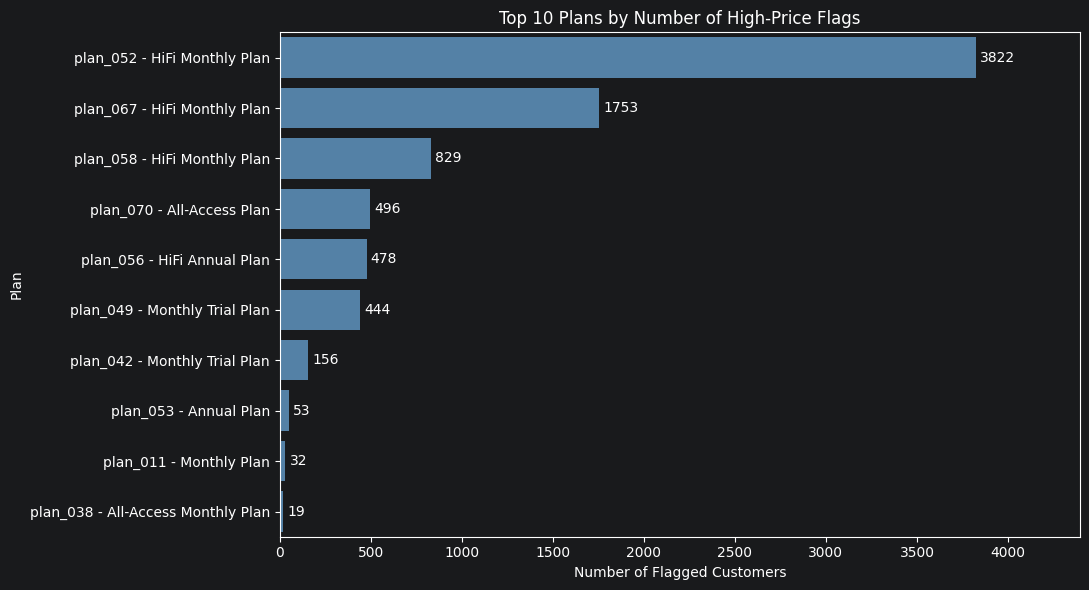

In [143]:
high_price_counts = (
    high_price_outliers
    .groupby(['primary_plan_id', 'primary_plan_name'])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='flagged_customers')
)

high_price_counts['plan'] = (
    high_price_counts['primary_plan_id'] + ' - ' +
    high_price_counts['primary_plan_name']
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=high_price_counts,
    x='flagged_customers',
    y='plan',
    color='steelblue'
)

ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
plt.xlim(0, high_price_counts['flagged_customers'].max() * 1.15)
plt.title('Top 10 Plans by Number of High-Price Flags')
plt.xlabel('Number of Flagged Customers')
plt.ylabel('Plan')
plt.tight_layout()
plt.show()

High-price flags are concentrated in three HiFi Monthly plan IDs, which together account for 6,404 of the 8,136 flagged customers, approximately 79%. The table also shows that many flagged customers share common price levels around `$24.99`.


## 4. Feature engineering and peer comparison

We select customer characteristics for comparing customers and predicting discount percentages: monthly list price, tenure, number of plans, plan ID, billing interval, and acquisition channel. Plan IDs distinguish subscriptions that share the same generalized name.

In [144]:
numeric_features = [
    'mrr_list',
    'tenure_days',
    'plan_count'
]

categorical_features = [
    'primary_plan_id',
    'interval',
    'acquisition_channel'
]

X = clean_data[numeric_features + categorical_features].copy()
y = clean_data['discount_pct'].copy()

X.head()


,mrr_list,tenure_days,plan_count,primary_plan_id,interval,acquisition_channel
0,12.50,2480,1,plan_053,year,discount
1,9.99,272,1,plan_009,month,full_price
2,24.99,23,1,plan_052,month,full_price
3,16.66,300,1,plan_035,year,discount
4,16.66,1723,1,plan_065,year,full_price


We exclude net revenue, discount amount, discount bucket, and recent coupon usage because they contain information about the current discount we want to predict. Customer identifiers and the constant billing interval count are also excluded. Historical discount percentages are left out of this initial baseline.

We will use 80% of the customers for training and reserve 20% for evaluating the baseline model. Encoding and scaling will be fitted using only the training data.

In [145]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)

Training set: (91456, 6)
Test set: (22865, 6)


Now standardize the numerical features and one-hot encode the categorical features, creating separate indicator columns for each category. Preprocessing will be fitted only on the training data.

In [146]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown='ignore'), categorical_features)
)

preprocessor

ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 ['mrr_list', 'tenure_days', 'plan_count']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['primary_plan_id', 'interval',
                                  'acquisition_channel'])])

## 5. Baseline model

As a baseline model and as discount percentage is a continuous target, we will use linear regression. A pipeline combines preprocessing and model fitting using only the training data. We evaluate predictions on the test set using MAE and RMSE, expressed in percentage points.

In [147]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Test MAE: {mae * 100:.2f} percentage points')
print(f'Test RMSE: {rmse * 100:.2f} percentage points')


Test MAE: 4.63 percentage points
Test RMSE: 9.46 percentage points


We compare linear regression against a simple benchmark that predicts the training-set average discount for every customer. Both are evaluated on the same test set, with lower MAE and RMSE indicating better predictions.

In [148]:
mean_pred = np.full(len(y_test), y_train.mean())

mean_mae = mean_absolute_error(y_test, mean_pred)
mean_rmse = np.sqrt(mean_squared_error(y_test, mean_pred))

model_comparison = pd.DataFrame({
    'Model': ['Training mean', 'Linear regression'],
    'MAE (percentage points)': [mean_mae * 100, mae * 100],
    'RMSE (percentage points)': [mean_rmse * 100, rmse * 100]
}).set_index('Model')

model_comparison.round(2)


,MAE (percentage points),RMSE (percentage points)
Model,,
Training mean,23.13,25.55
Linear regression,4.63,9.46


Linear regression reduced MAE from 23.13 to 4.63 percentage points and RMSE from 25.55 to 9.46, improvements of approximately 80% and 63%, respectively. Customer characteristics therefore help predict observed discounts better than using one overall average.

We use MAE because it expresses average prediction error in easily understood percentage points. We also report RMSE because it gives greater weight to large errors. A test MAE of 4.63 means predictions differ from actual discounts by 4.63 percentage points on average.

Linear regression does not constrain predictions to the valid discount range of 0% to 100%. We check how often predictions fall outside these limits.

In [149]:
below_zero = y_pred < 0
above_one = y_pred > 1
outside_range = below_zero | above_one

print(f'Lowest prediction: {y_pred.min() * 100:.2f}%')
print(f'Highest prediction: {y_pred.max() * 100:.2f}%')
print(f'Predictions below 0%: {below_zero.sum():,}')
print(f'Predictions above 100%: {above_one.sum():,}')
print(f'Outside valid range: {outside_range.mean() * 100:.2f}%')

Lowest prediction: -5.08%
Highest prediction: 77.32%
Predictions below 0%: 6,956
Predictions above 100%: 0
Outside valid range: 30.42%


Predictions ranged from −5.08% to 77.32%. Of the test predictions, 6,956 (30.42%) were below 0%, while none exceeded 100%. Although linear regression outperformed the average-discount benchmark, it does not always produce valid discount percentages. We retain the original predictions for evaluation and record this as a limitation to address in future modeling.

## 6. Peer comparison

The capstone’s main objective is to identify unusual discounts among comparable customers, not to build a discount prediction tool. The previous regression model provides an initial predictive baseline, while peer comparison directly explores potential discount inconsistencies.

We begin by comparing discounts among customers with the same plan ID and billing interval. These are preliminary peer groups: differences in subscription value and tenure will also need consideration before flagging unusual discounts.


In [150]:
peer_summary = clean_data.groupby(
    ['primary_plan_id', 'interval']
).agg(
    customers=('customer_key', 'count'),
    min_discount=('discount_pct', 'min'),
    q1_discount=('discount_pct', lambda x: x.quantile(0.25)),
    median_discount=('discount_pct', 'median'),
    q3_discount=('discount_pct', lambda x: x.quantile(0.75)),
    max_discount=('discount_pct', 'max')
)

# Display discounts as percentages
discount_columns = ['min_discount', 'q1_discount', 'median_discount','q3_discount', 'max_discount']

peer_summary[discount_columns] *= 100

peer_summary = peer_summary.sort_values('customers', ascending=False)
peer_summary.head(15).round(2)

,,customers,min_discount,q1_discount,median_discount,q3_discount,max_discount
primary_plan_id,interval,,,,,,
plan_065,year,19333,0.00,50.01,50.01,50.01,50.01
plan_011,month,18387,0.00,0.00,0.00,0.00,49.97
plan_040,month,11691,0.00,66.71,66.71,66.71,100.00
plan_053,year,9222,0.00,0.00,0.00,0.00,50.00
plan_035,year,8338,25.00,50.01,50.01,50.01,50.01
plan_068,year,6547,0.00,0.00,0.00,0.00,0.00
plan_044,year,5599,0.00,0.00,0.00,0.00,50.00
plan_001,month,5138,8.01,13.34,13.34,13.34,100.00
plan_052,month,3822,0.00,0.00,0.00,0.00,0.00


In [151]:
peer_characteristics = clean_data.groupby(
    ['primary_plan_id', 'interval']
).agg(
    customers=('customer_key', 'count'),
    min_list_price=('mrr_list', 'min'),
    max_list_price=('mrr_list', 'max'),
    min_tenure_days=('tenure_days', 'min'),
    max_tenure_days=('tenure_days', 'max'),
    min_plan_count=('plan_count', 'min'),
    max_plan_count=('plan_count', 'max')
)

peer_characteristics = peer_characteristics.sort_values('customers', ascending=False)
peer_characteristics.head(15).round(2)

,,customers,min_list_price,max_list_price,min_tenure_days,max_tenure_days,min_plan_count,max_plan_count
primary_plan_id,interval,,,,,,,
plan_065,year,19333,16.66,31.66,230,3968,1,2
plan_011,month,18387,14.99,32.48,0,3969,1,3
plan_040,month,11691,10.00,74.95,37,3963,1,1
plan_053,year,9222,12.50,29.17,0,3969,1,2
plan_035,year,8338,16.66,24.99,263,3899,1,2
plan_068,year,6547,12.50,22.49,1,4344,1,2
plan_044,year,5599,12.50,22.49,126,3949,1,2
plan_001,month,5138,2.00,24.98,0,3783,1,2
plan_052,month,3822,24.99,24.99,2,4344,1,1


Customers sharing a primary plan can still differ in subscription value, tenure, and number of plans. These differences may help explain discount variation, so plan ID and billing interval alone are insufficient for defining comparable customers. We will refine the peer groups before flagging unusual discounts.


Let's refine the groups using plan ID, billing interval, monthly list value, plan count, and tenure band. These broad tenure bands are an initial choice. We check group sizes before identifying unusual discounts.

In [152]:
peer_data = clean_data.copy()

peer_data['tenure_band'] = pd.cut(
    peer_data['tenure_days'],
    bins=[0, 365, 1095, 1825, np.inf],
    labels=['Under 1 year', '1 to 3 years', '3 to 5 years', '5+ years'],
    right=False
)

peer_columns = [
    'primary_plan_id',
    'interval',
    'mrr_list',
    'plan_count',
    'tenure_band'
]

peer_sizes = peer_data.groupby(
    peer_columns, observed=True
).size()

peer_sizes.describe().round(2)

count     337.00
mean      339.23
std      1065.29
min         1.00
25%         2.00
50%        10.00
75%       140.00
max      9330.00
dtype: float64

For this initial analysis, we consider groups containing at least 10 customers. Customers in smaller groups remain in the dataset but will not be assessed for unusual discounts using this approach.


In [153]:
min_group_size = 10

eligible_groups = peer_sizes[peer_sizes >= min_group_size]
customers_covered = eligible_groups.sum()

print('Eligible groups:', len(eligible_groups))
print('Customers covered:', customers_covered)
print(f'Customer coverage: {customers_covered / len(peer_data) * 100:.2f}%')
print('Customers in smaller groups:', len(peer_data) - customers_covered)


Eligible groups: 170
Customers covered: 113882
Customer coverage: 99.62%
Customers in smaller groups: 439


The refined peer groups cover 99.62% of cleaned customers using a minimum group size of 10. The remaining 439 customers belong to smaller groups and are not assessed by this method. This provides broad coverage, although group definitions and the minimum size remain exploratory choices.

Our peer groups are based on the following characteristics:

- **Plan ID:** the same actual plan, not just the generalized name.
- **Billing interval:** monthly or annual.
- **Monthly list value (`mrr_list`):** the same value before discounts.
- **Plan count:** the same number of active plans.
- **Tenure band:** under 1 year, 1–3 years, 3–5 years, or 5+ years

We then compare each customer’s discount with the group median. Positive gaps indicate higher discounts than the median, negative gaps indicate lower discounts.

In [154]:
group_reference = peer_data.groupby(
    peer_columns, observed=True
).agg(
    group_size=('customer_key', 'count'),
    peer_median_discount=('discount_pct', 'median')
).reset_index()

group_reference = group_reference[
    group_reference['group_size'] >= min_group_size
]

peer_comparison = peer_data.merge(
    group_reference,
    on=peer_columns,
    how='inner'
)

peer_comparison['discount_gap_pp'] = (
    peer_comparison['discount_pct']
    - peer_comparison['peer_median_discount']
) * 100

peer_comparison['discount_gap_pp'].describe().round(2)

count    113882.00
mean          0.27
std           3.45
min         -66.71
25%           0.00
50%           0.00
75%           0.00
max          50.00
Name: discount_gap_pp, dtype: float64

113,882 customers with gaps ranging from **−66.71 to +50 percentage points**. The median and both quartiles are zero.


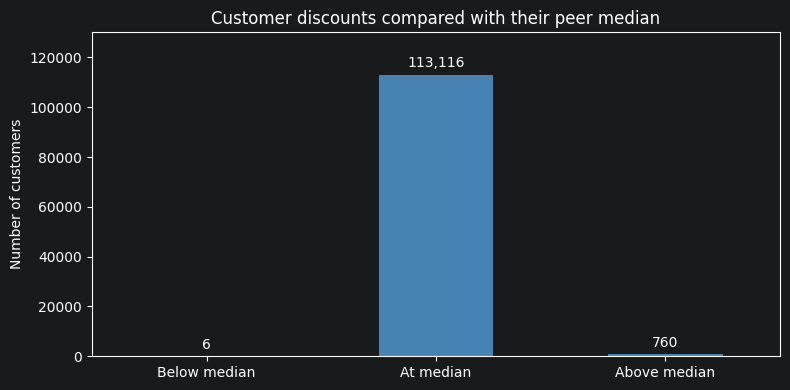

In [155]:
gap = peer_comparison['discount_gap_pp']

gap_counts = pd.Series({
    'Below median': (gap < 0).sum(),
    'At median': (gap == 0).sum(),
    'Above median': (gap > 0).sum()
})

ax = gap_counts.plot(
    kind='bar',
    figsize=(8, 4),
    color='steelblue',
    rot=0
)

ax.bar_label(
    ax.containers[0],
    labels=[f'{count:,}' for count in gap_counts],
    padding=3
)

ax.set_title('Customer discounts compared with their peer median')
ax.set_ylabel('Number of customers')
ax.margins(y=0.15)
plt.tight_layout()
plt.show()


This chart shows how many customers receive discounts below, equal to, or above their peer-group median. It shows the direction of the differences, not their size.

We can use an exploratory cutoff of 10 percentage points to identify discounts that differ substantially from their peer-group median.

For each customer, we compare their actual discount with the median discount of similar customers. For example, if the group median is 50%, customers receiving 40% or less, or 60% or more, are flagged because the difference is at least 10 percentage points. We chose 10 points as an initial rule to focus on larger differences. The group median is a reference for comparison, not the discount a customer should necessarily receive.

In [156]:
gap_threshold_pp = 10

peer_comparison['absolute_gap_pp'] = (
    peer_comparison['discount_gap_pp'].abs()
)

review_candidates = peer_comparison[
    peer_comparison['absolute_gap_pp'] >= gap_threshold_pp
].copy()

print('Customers flagged for review:', len(review_candidates))
print(
    f'Share of assessed customers: '
    f'{len(review_candidates) / len(peer_comparison) * 100:.2f}%'
)

# Show the five largest gaps
review_examples = review_candidates.nlargest(5, 'absolute_gap_pp')[
    ['customer_key', 'primary_plan_id', 'group_size',
     'discount_pct', 'peer_median_discount', 'discount_gap_pp']
].copy()

# Display both discounts as percentages
review_examples[['discount_pct', 'peer_median_discount']] *= 100

review_examples.round(2)

Customers flagged for review: 764
Share of assessed customers: 0.67%


,customer_key,primary_plan_id,group_size,discount_pct,peer_median_discount,discount_gap_pp
38176,customer_3c9268a0cc3245a2e08222d7,plan_040,9330,0.0,66.71,-66.71
47884,customer_39c3938dd9d793e153b71d52,plan_040,1050,0.0,66.71,-66.71
489,customer_7037c1891ac1472914b3dc1c,plan_044,2945,50.0,0.00,50.00
497,customer_66000996dfe96a422f9ca447,plan_055,958,50.0,0.00,50.00
1379,customer_c9c29cb87a363c2adcf2ab09,plan_044,1784,50.0,0.00,50.00


This rule flagged 764 customers, or 0.67% of those assessed. Examples include customers receiving no discount where their group median was 66.71%, and customers receiving 50% where the median was 0%.

## 7. Findings and limitations

### Findings

- After cleaning, the dataset contains **114,321 customers**.
- Linear regression outperformed the average-discount benchmark, with a test MAE of **4.63** and RMSE of **9.46 percentage points**.
- Most assessed customers matched their peer-group median discount. However, **764 customers (0.67% of those assessed)** differed by at least 10 percentage points and were flagged for review.
- Discounts concentrate around 0%, 50%, and 67%, suggesting common discount tiers.

### Limitations

- Linear regression produced negative discounts for **30.42% of test predictions**, limiting its practical use.
- Peer groups and review thresholds are exploratory choices. **439 customers** had insufficient peers and were not assessed.
- Flagged differences do not prove incorrect pricing. Other business circumstances may explain them.

### Next steps

- Review flagged cases and test alternative peer groups and thresholds in the next project phase.